In [1]:
# Project setup
import sys
import os

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [2]:
import pandas as pd
import numpy as np

from src.data.loaders import PointsDataset
from src.visualization.visualization_utils import create_meshgrid
from src.visualization.feature_space_plots import plot_in_rectangular_coordinates
from src.data.synthetic import generate_custom_polar_dataset
from src.features.transformations import cartesian_to_polar, polar_to_curvilinear_r2cos2theta, polar_to_cartesian

from src.visualization.decision_boundaries import plot_decision_boundary
from sklearn.linear_model import LogisticRegression
from src.evaluation.metrics import ModelMetrics
from src.models.model_utilities import Model1DWrapper
from sklearn.svm import SVC

In [3]:
random_state = 42

# Dataset Sample with Noise

In [4]:
r_cutoff = 1.0
noise = 0.1
num_class_points = 80

In [5]:
synth_polar_pos_dataset = generate_custom_polar_dataset(
    label=1,
    num_points=num_class_points,
    theta_noise=noise,
    r_noise=noise
)

synth_polar_neg_dataset = generate_custom_polar_dataset(
    label=0,
    num_points=num_class_points,
    r_inner_bound_func=lambda theta: np.array([1]*theta.size),
    r_outer_bound_func=lambda theta: np.array([2]*theta.size),
    theta_noise=noise,
    r_noise=noise
)

synth_polar_dataset = PointsDataset.merge_dataset(synth_polar_pos_dataset, synth_polar_neg_dataset)


synth_cartesian_dataset = synth_polar_dataset.transform(polar_to_cartesian)

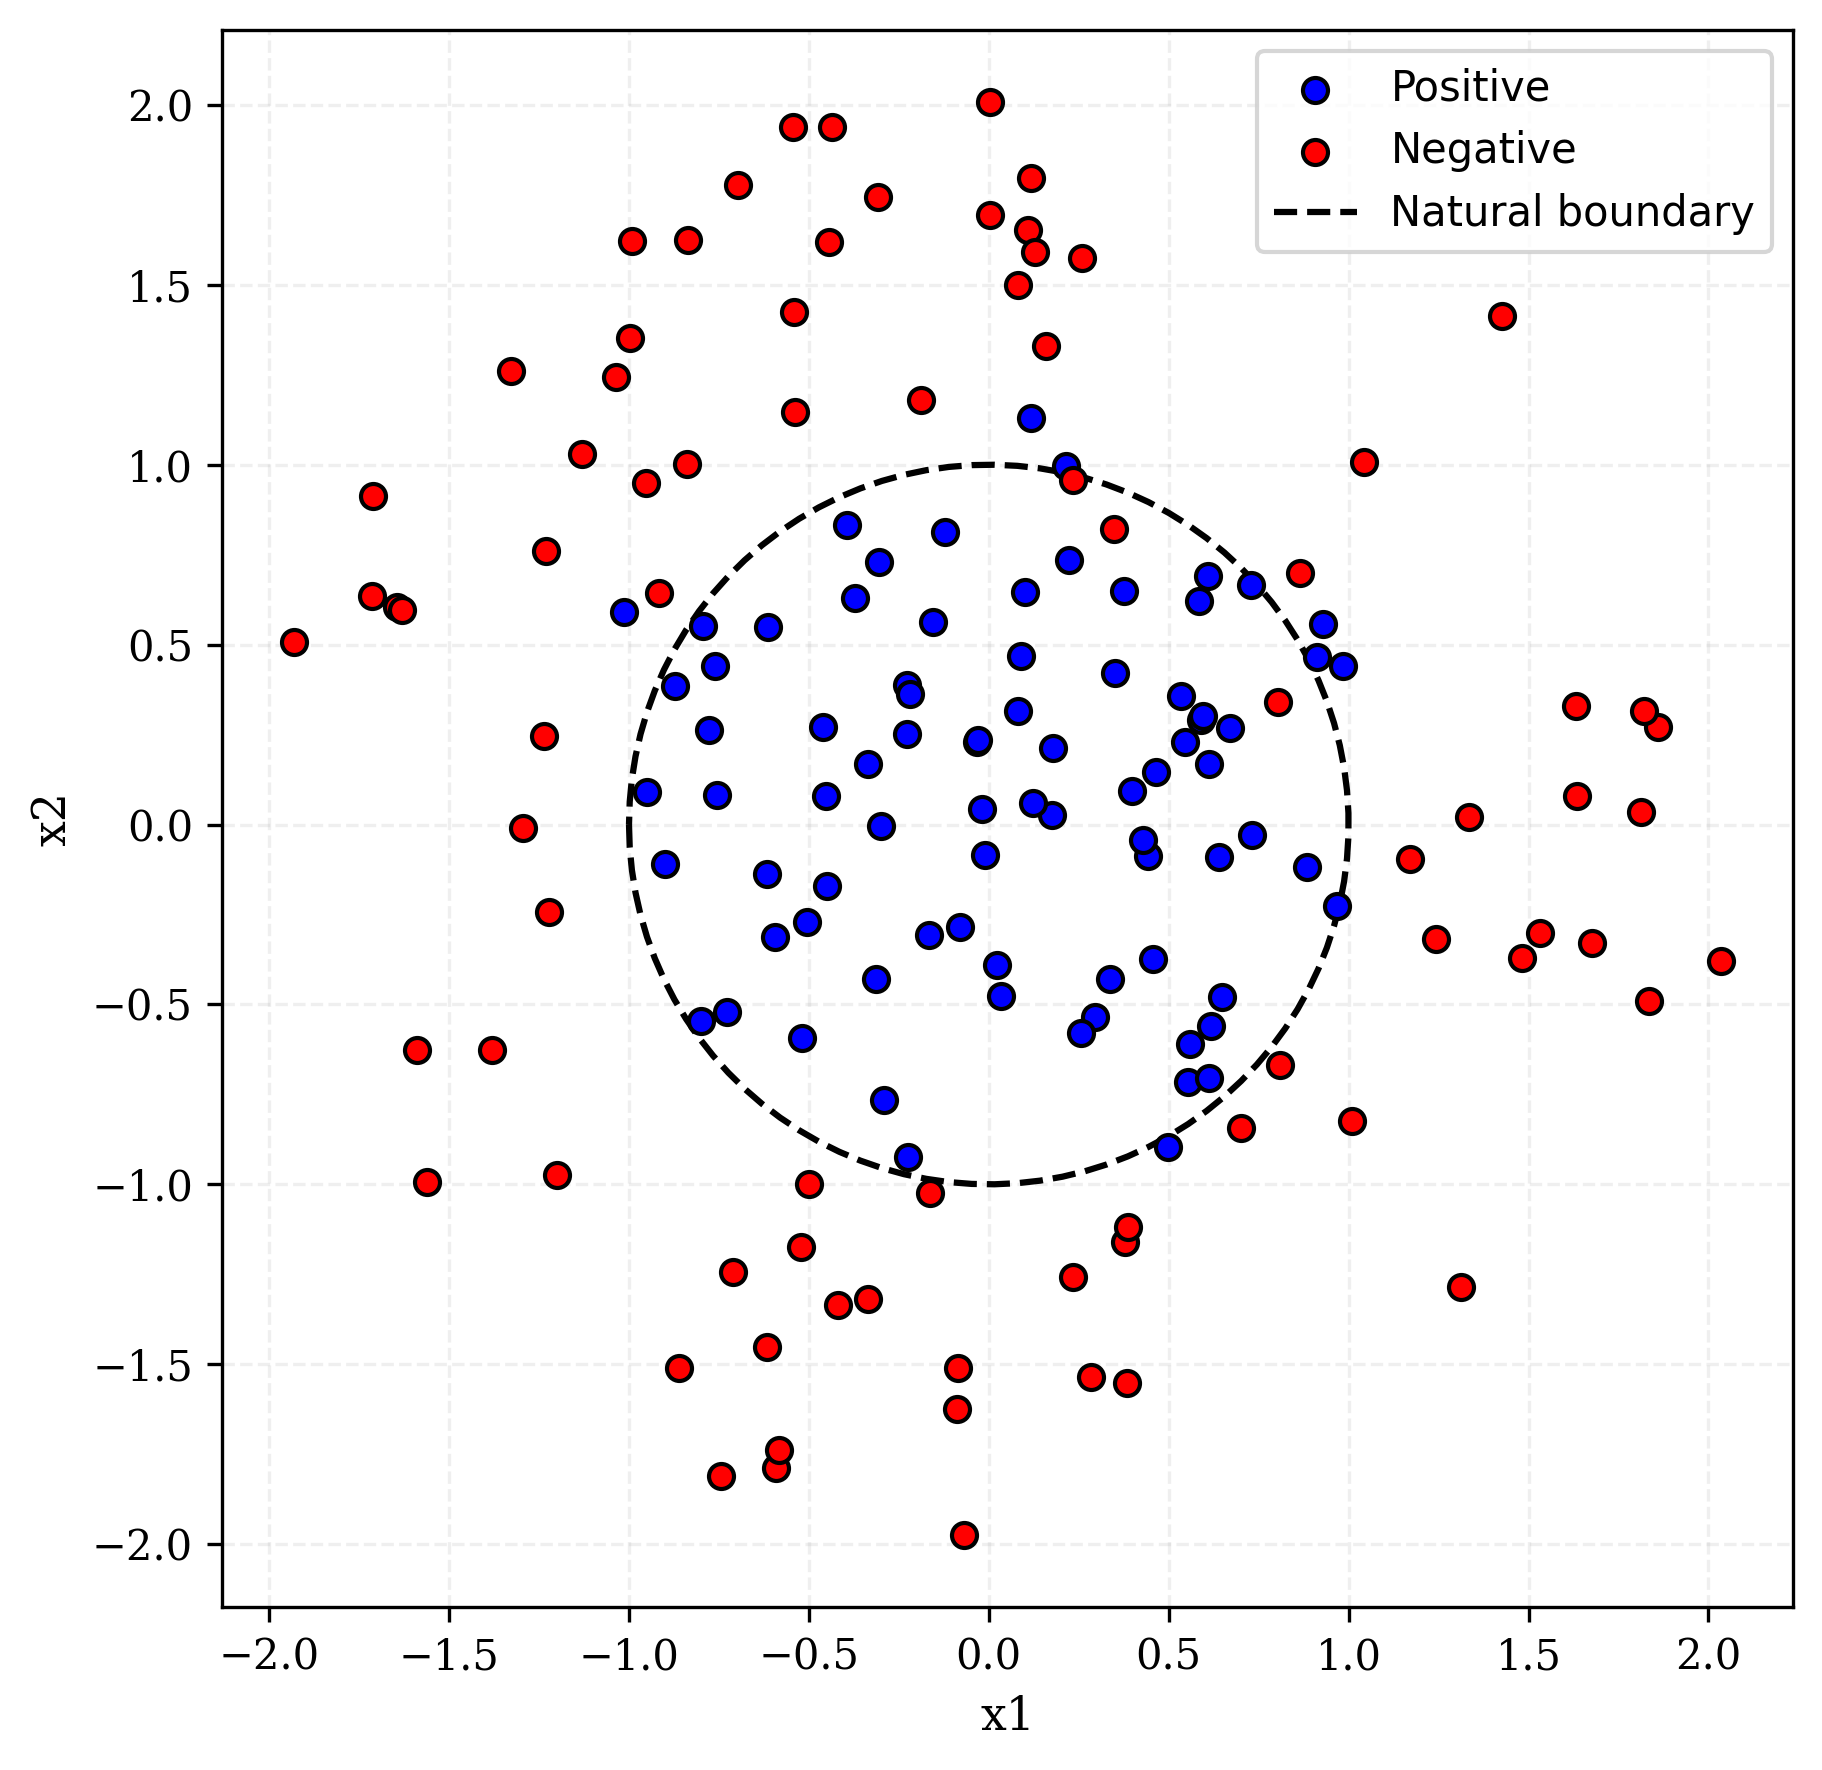

In [6]:
sample_fig, sample_ax = plot_in_rectangular_coordinates(
    synth_cartesian_dataset.X, 
    synth_cartesian_dataset.y,
    title=""
)

Thetas = np.linspace(-np.pi, np.pi, 100)
sample_ax.plot(r_cutoff*np.cos(Thetas), r_cutoff*np.sin(Thetas), color='black', linestyle='--', label='Natural boundary')
sample_ax.legend()
sample_ax.set_aspect('equal')

display(sample_fig)

In [7]:
TP_ref = len(synth_polar_dataset.X[(synth_polar_dataset.X['x1']<=r_cutoff) & (synth_polar_dataset.y==1)])
TN_ref = len(synth_polar_dataset.X[(synth_polar_dataset.X['x1']>r_cutoff) & (synth_polar_dataset.y==0)])

reference_metrics = {
    'accuracy': (TP_ref + TN_ref)/(2*num_class_points),
    'precision': TP_ref/(TP_ref + (num_class_points-TN_ref)),
    'recall': TP_ref/(num_class_points)
}
reference_metrics['f1'] = 2 * (reference_metrics['precision'] * reference_metrics['recall']) / (reference_metrics['precision'] + reference_metrics['recall'])
metrics_df = pd.DataFrame(reference_metrics, index=['Generator decision boundary'])
display(metrics_df)

,accuracy,precision,recall,f1
Generator decision boundary,0.9375,0.960526,0.9125,0.935897


## Decision Boundaries

In [8]:
# Create a Cartesian meshgrid to plot decision boundaries
grid_x, grid_y, grid_cartesian = create_meshgrid(synth_cartesian_dataset.X, resolution=500)

# Transform meshgrid into polar grid
grid_polar = cartesian_to_polar(grid_x.ravel(), grid_y.ravel())

# Transform polar into curvilinear grid
grid_r2cos2_sqd = pd.DataFrame({'x1': grid_polar['x1']**2, 'x2': np.cos(grid_polar['x2'])**2})

# Transform data points from polar into curvilinear form
synth_r2cos2_dataset = synth_polar_dataset.transform(
    polar_to_curvilinear_r2cos2theta, new_coordinate_system='r2cos2',
    new_feature_mapping={'x1': 'r2', 'x2': 'cos2()'}
)

### Logistic

In [9]:
lr_model = LogisticRegression(random_state=random_state)
lr_model.fit(synth_polar_dataset.X, synth_polar_dataset.y)
lr_metrics = ModelMetrics('Logistic Regression', 'Polar', synth_polar_dataset.y, lr_model.predict(synth_polar_dataset.X))
lr_metrics.compute_metrics()
metrics_df = pd.concat([metrics_df, lr_metrics.to_pandas().rename(index={0:'Logistic Regression | Polar'})])

lr_fig, lr_ax = plot_decision_boundary(
    model=lr_model, dataset_X=synth_cartesian_dataset.X, dataset_y=synth_cartesian_dataset.y,
    prediction_domain=grid_polar, grid_x=grid_x, grid_y=grid_y,
    title=f'model: Logistic | dataset: Synthetic Polar',
    metrics=lr_metrics.to_dict()
)

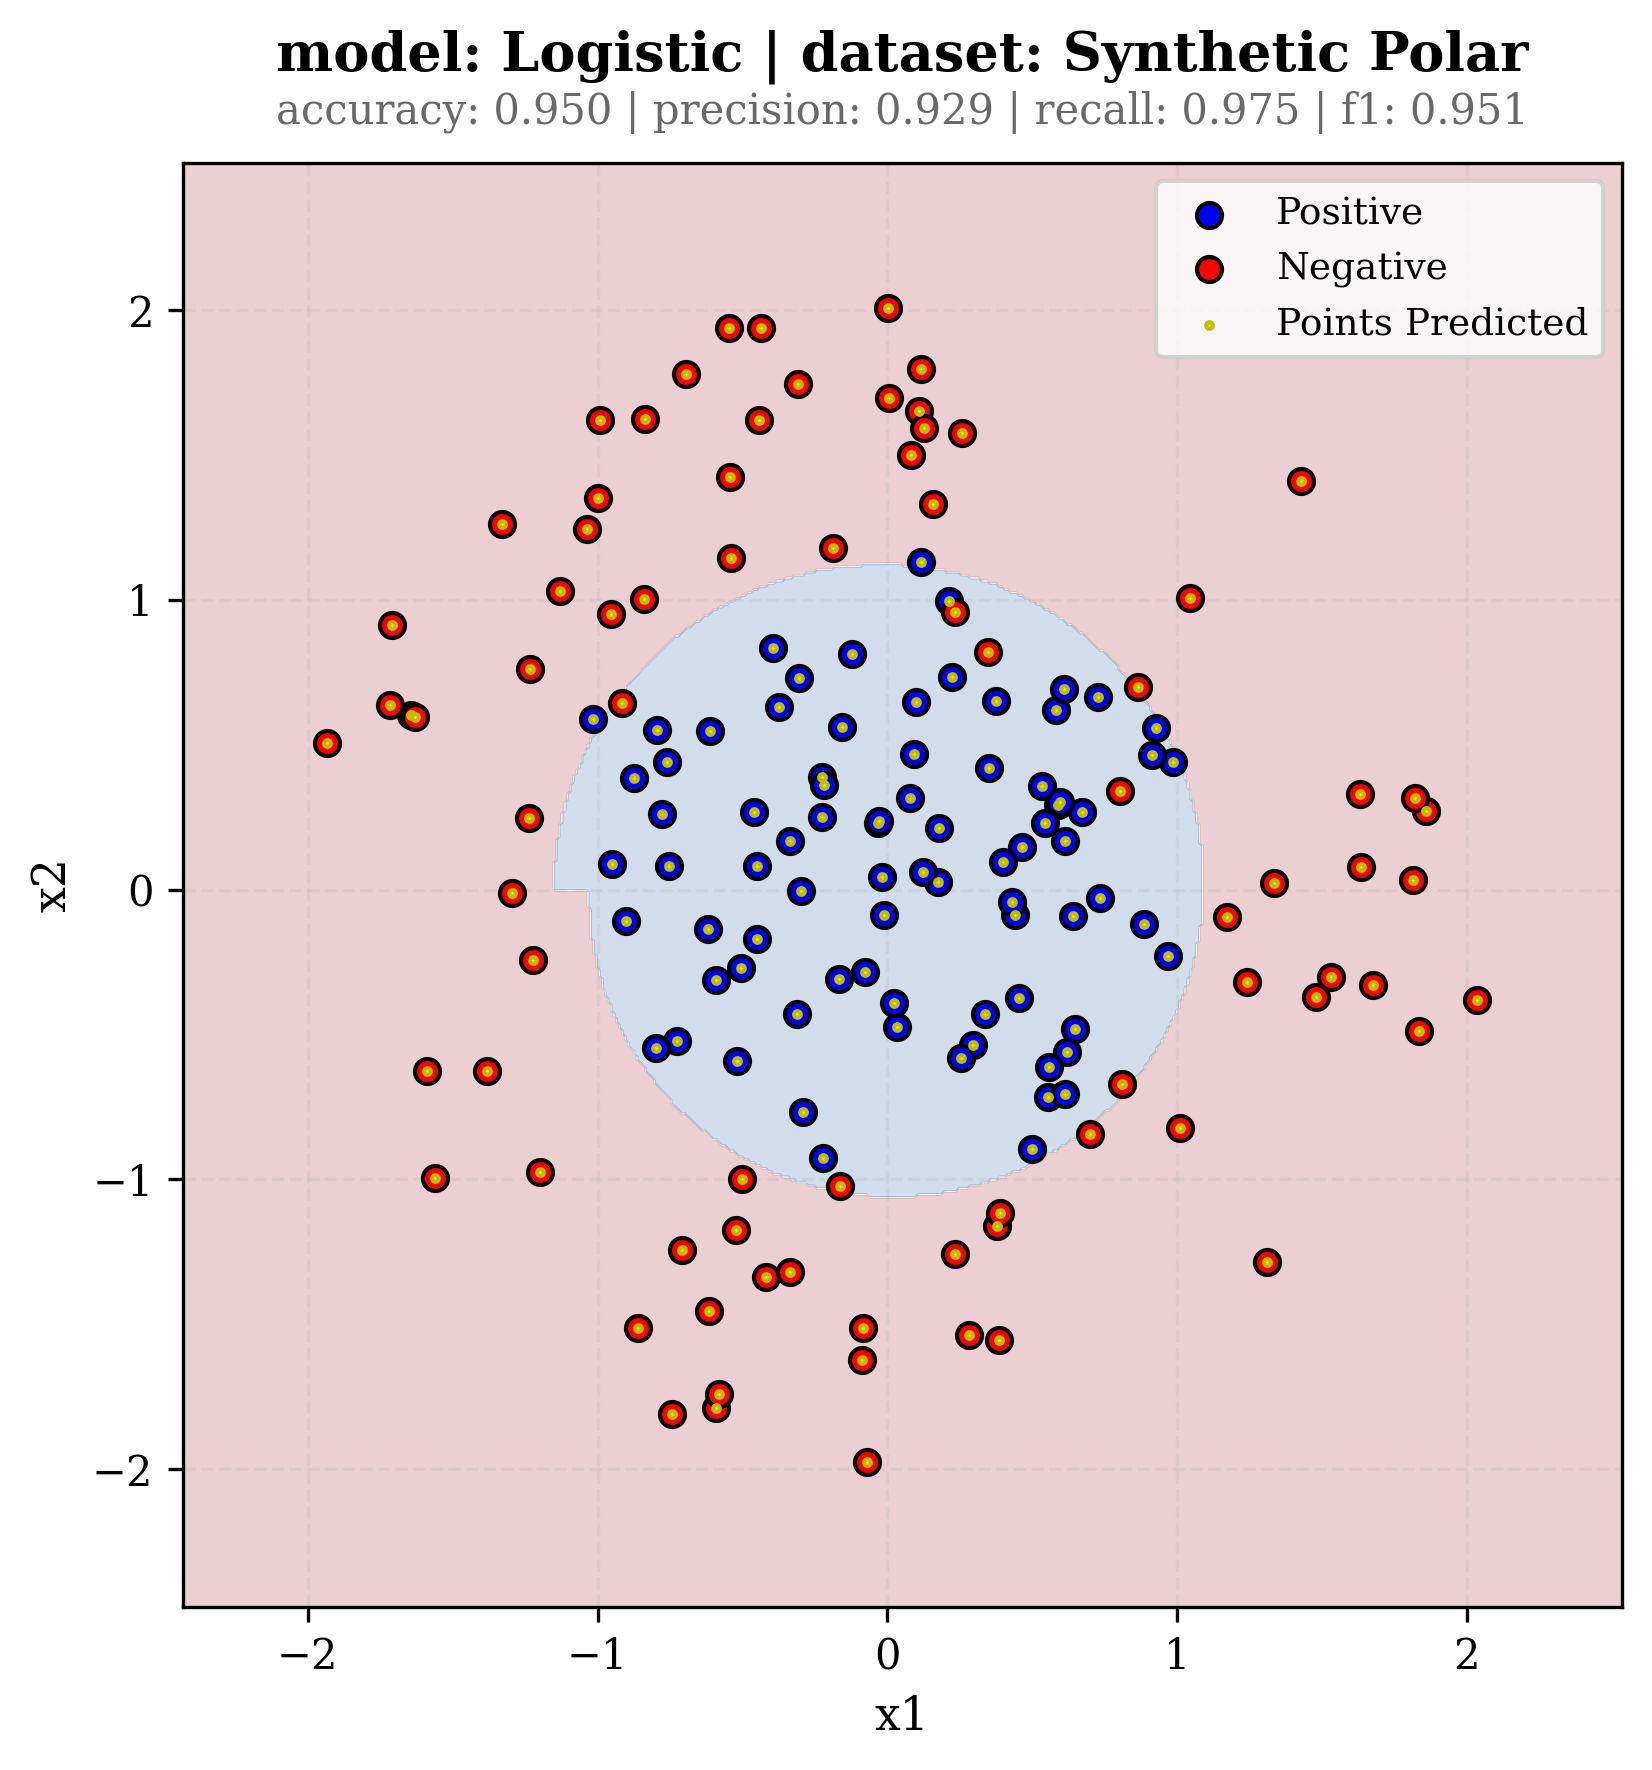

In [10]:
lr_ax.set_aspect('equal')
display(lr_fig)

### Logistic on Radius Only

In [11]:
lr_modelR = LogisticRegression(random_state=random_state)
lr_modelR.fit(synth_polar_dataset.X[['x1']], synth_polar_dataset.y)
lr_metricsR = ModelMetrics('Logistic Regression', 'R-only', synth_polar_dataset.y, lr_modelR.predict(synth_polar_dataset.X[['x1']]))
lr_metricsR.compute_metrics()
metrics_df = pd.concat([metrics_df, lr_metricsR.to_pandas().rename(index={0:'Logistic Regression | R-only'})])

wrapped_modelR = Model1DWrapper(trained_model=lr_modelR, vars_list=['x1'])

lr_R_fig, lr_R_ax = plot_decision_boundary(
    model=wrapped_modelR, dataset_X=synth_cartesian_dataset.X, dataset_y=synth_cartesian_dataset.y,
    prediction_domain=grid_polar, grid_x=grid_x, grid_y=grid_y,
    title=f'model: Logistic | dataset: Synthetic R-only',
    metrics=lr_metricsR.to_dict()
)

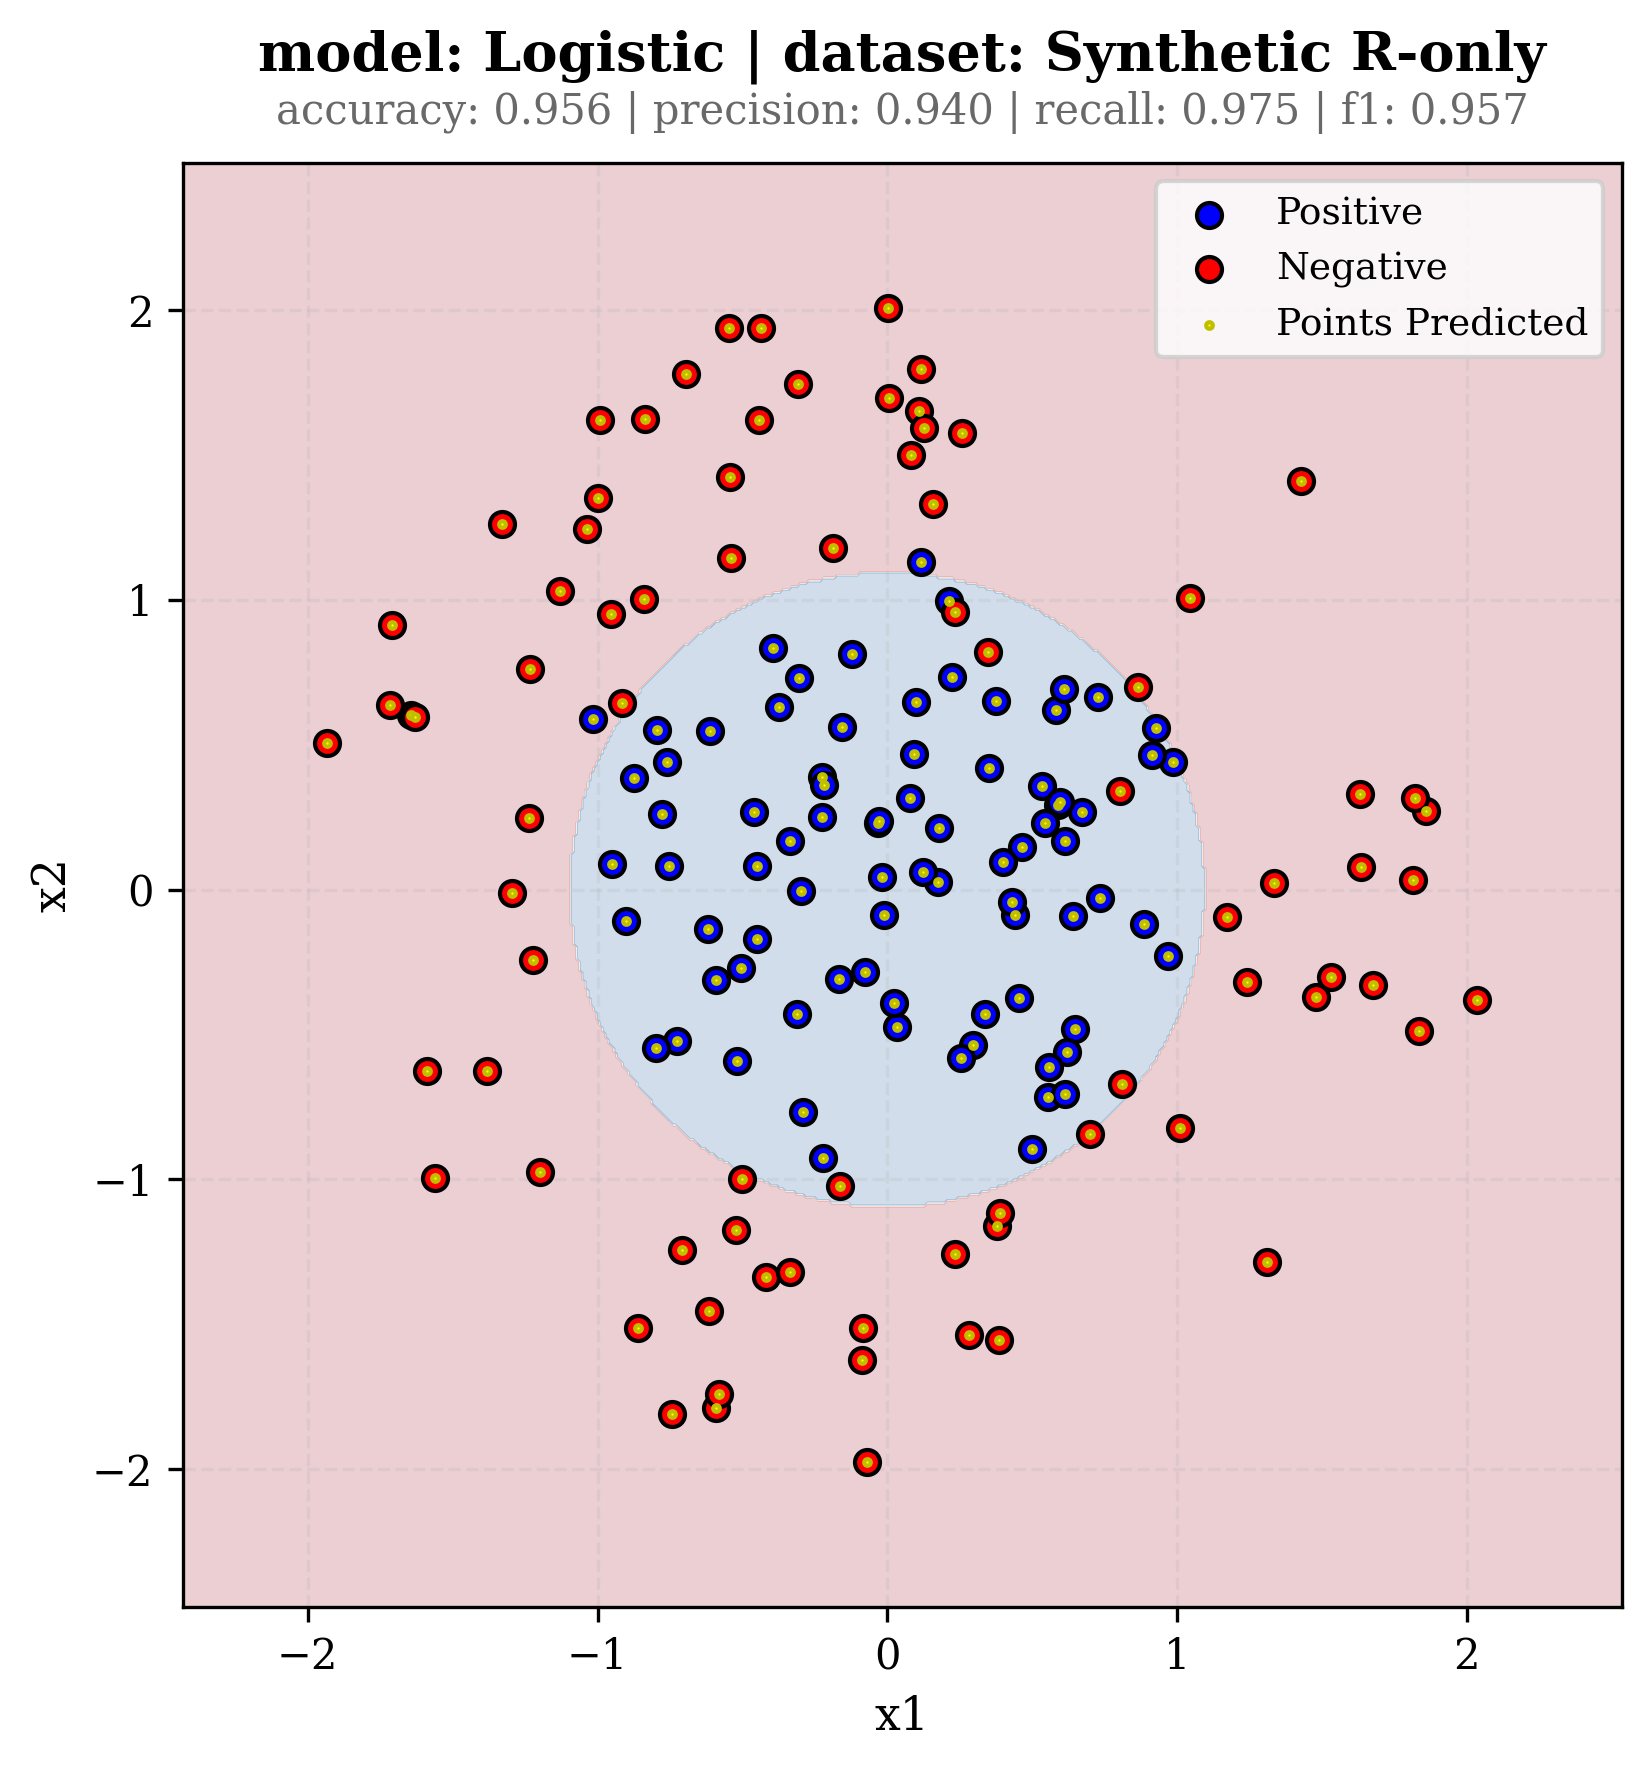

In [12]:
lr_R_ax.set_aspect('equal')
display(lr_R_fig)

### Logistic on Featured Coordinates

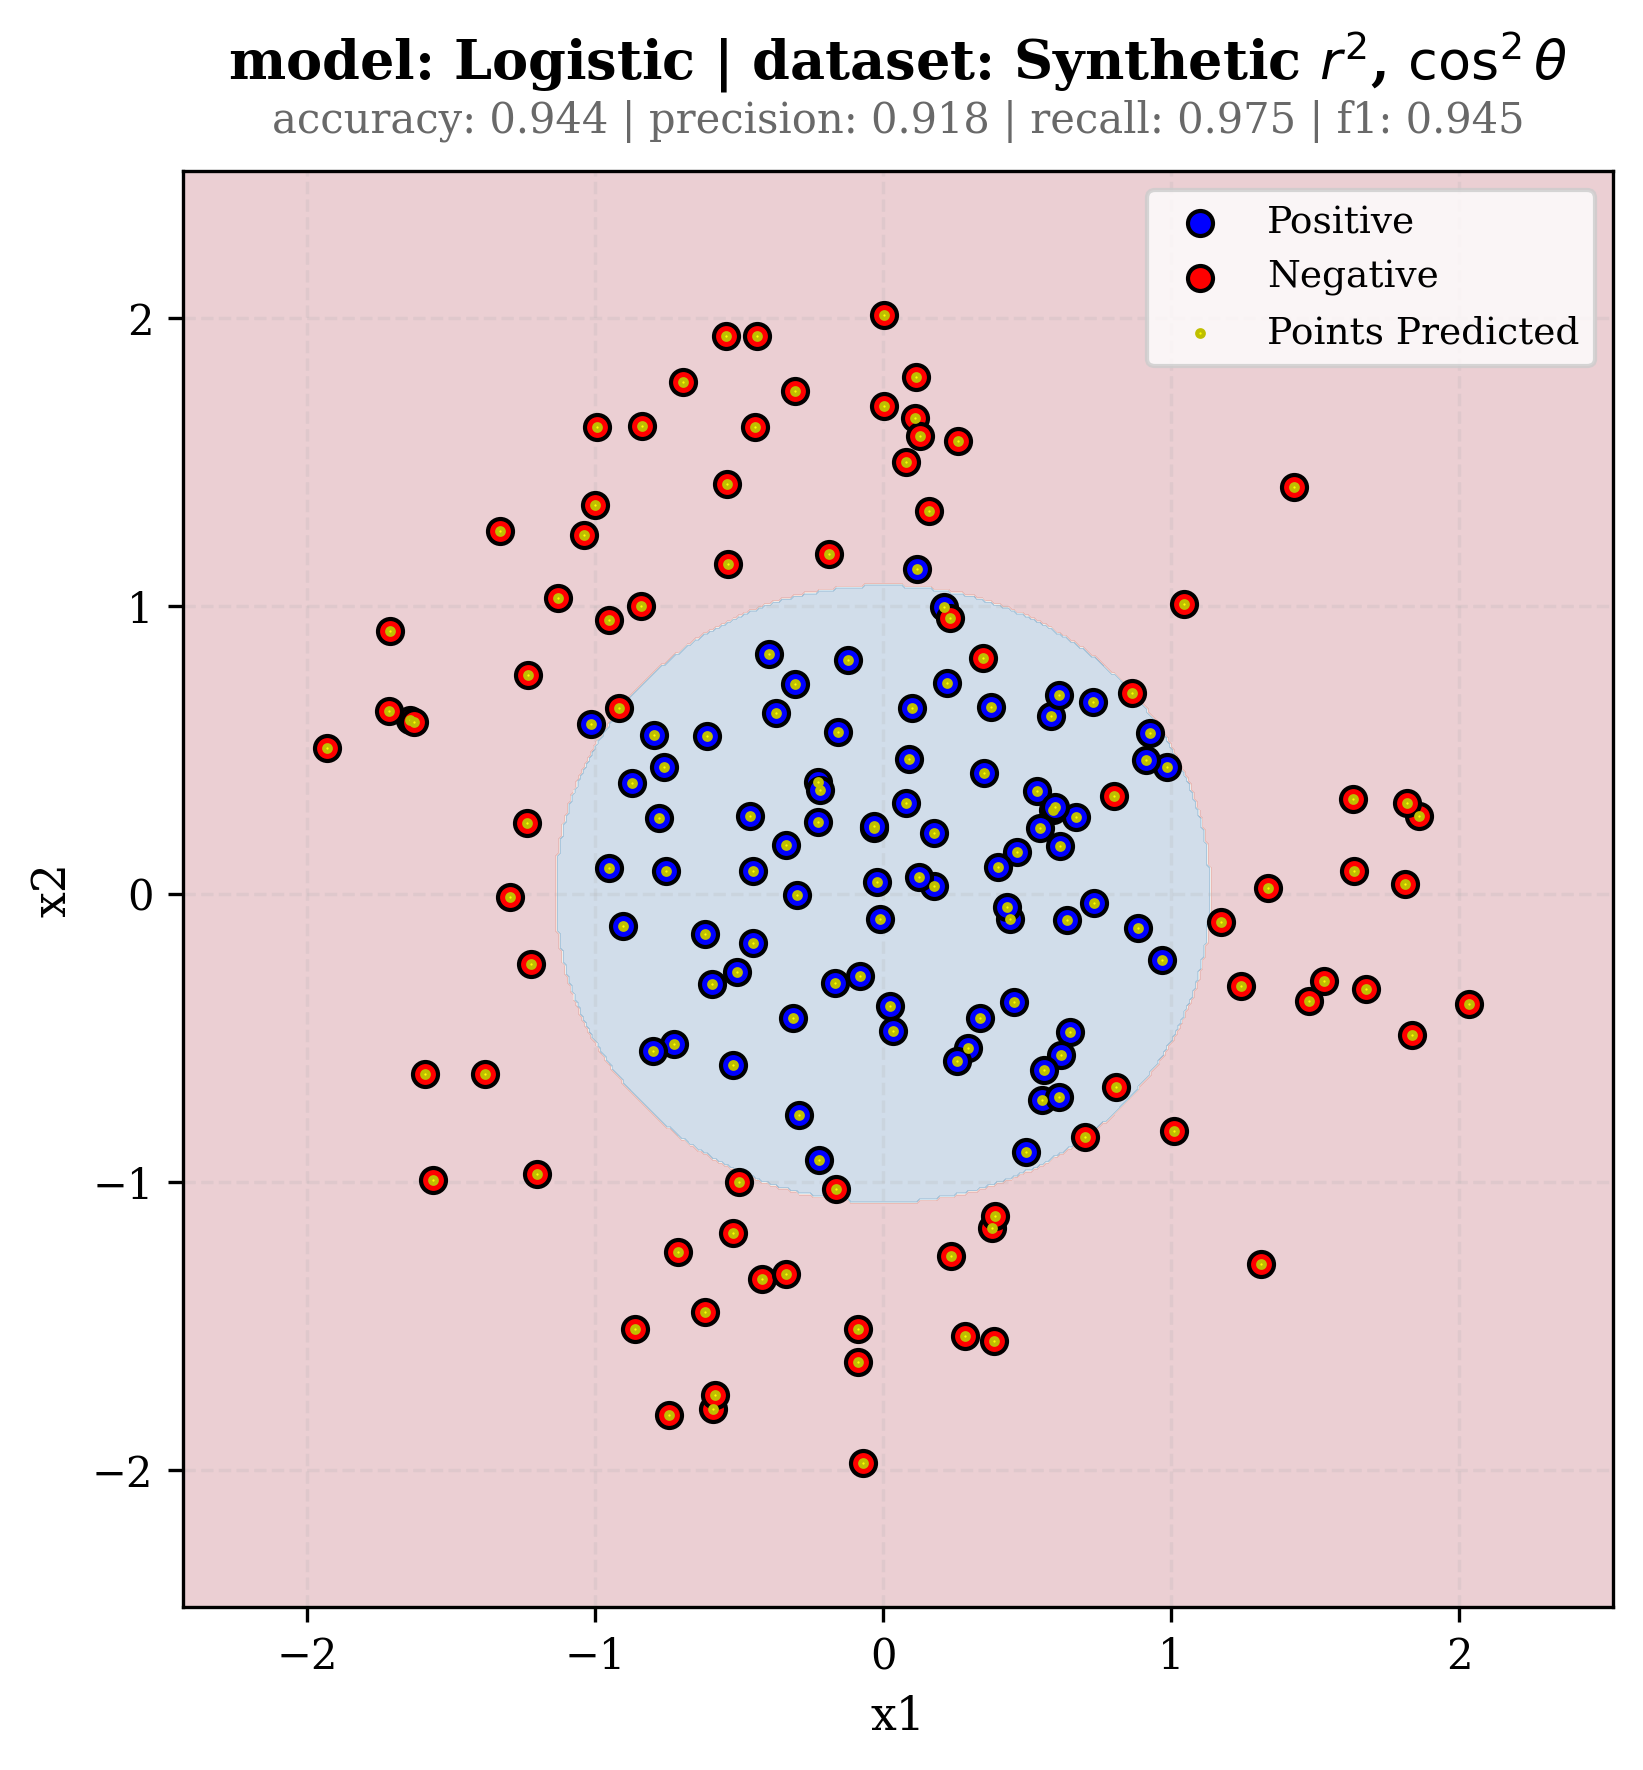

In [13]:
lr_model_cos2 = LogisticRegression(random_state=42)
lr_model_cos2.fit(synth_r2cos2_dataset.X, synth_r2cos2_dataset.y)
lr_metrics_cos2 = ModelMetrics('Logistic Regression', 'r^2,cos2()', synth_r2cos2_dataset.y, lr_model_cos2.predict(synth_r2cos2_dataset.X))
lr_metrics_cos2.compute_metrics()
metrics_df = pd.concat([metrics_df, lr_metrics_cos2.to_pandas().rename(index={0:'Logistic Regression | Curvilinear'})])

dataset_label = r'$\cos^2{\theta}$'

lr_fig, lr_ax = plot_decision_boundary(
    model=lr_model_cos2, dataset_X=synth_cartesian_dataset.X, dataset_y=synth_cartesian_dataset.y,
    prediction_domain=grid_r2cos2_sqd, grid_x=grid_x, grid_y=grid_y,
    title=f'model: Logistic | dataset: Synthetic $r^2$, {dataset_label}',
    metrics=lr_metrics_cos2.to_dict()
)
lr_ax.set_aspect('equal')
display(lr_fig)

### SVM

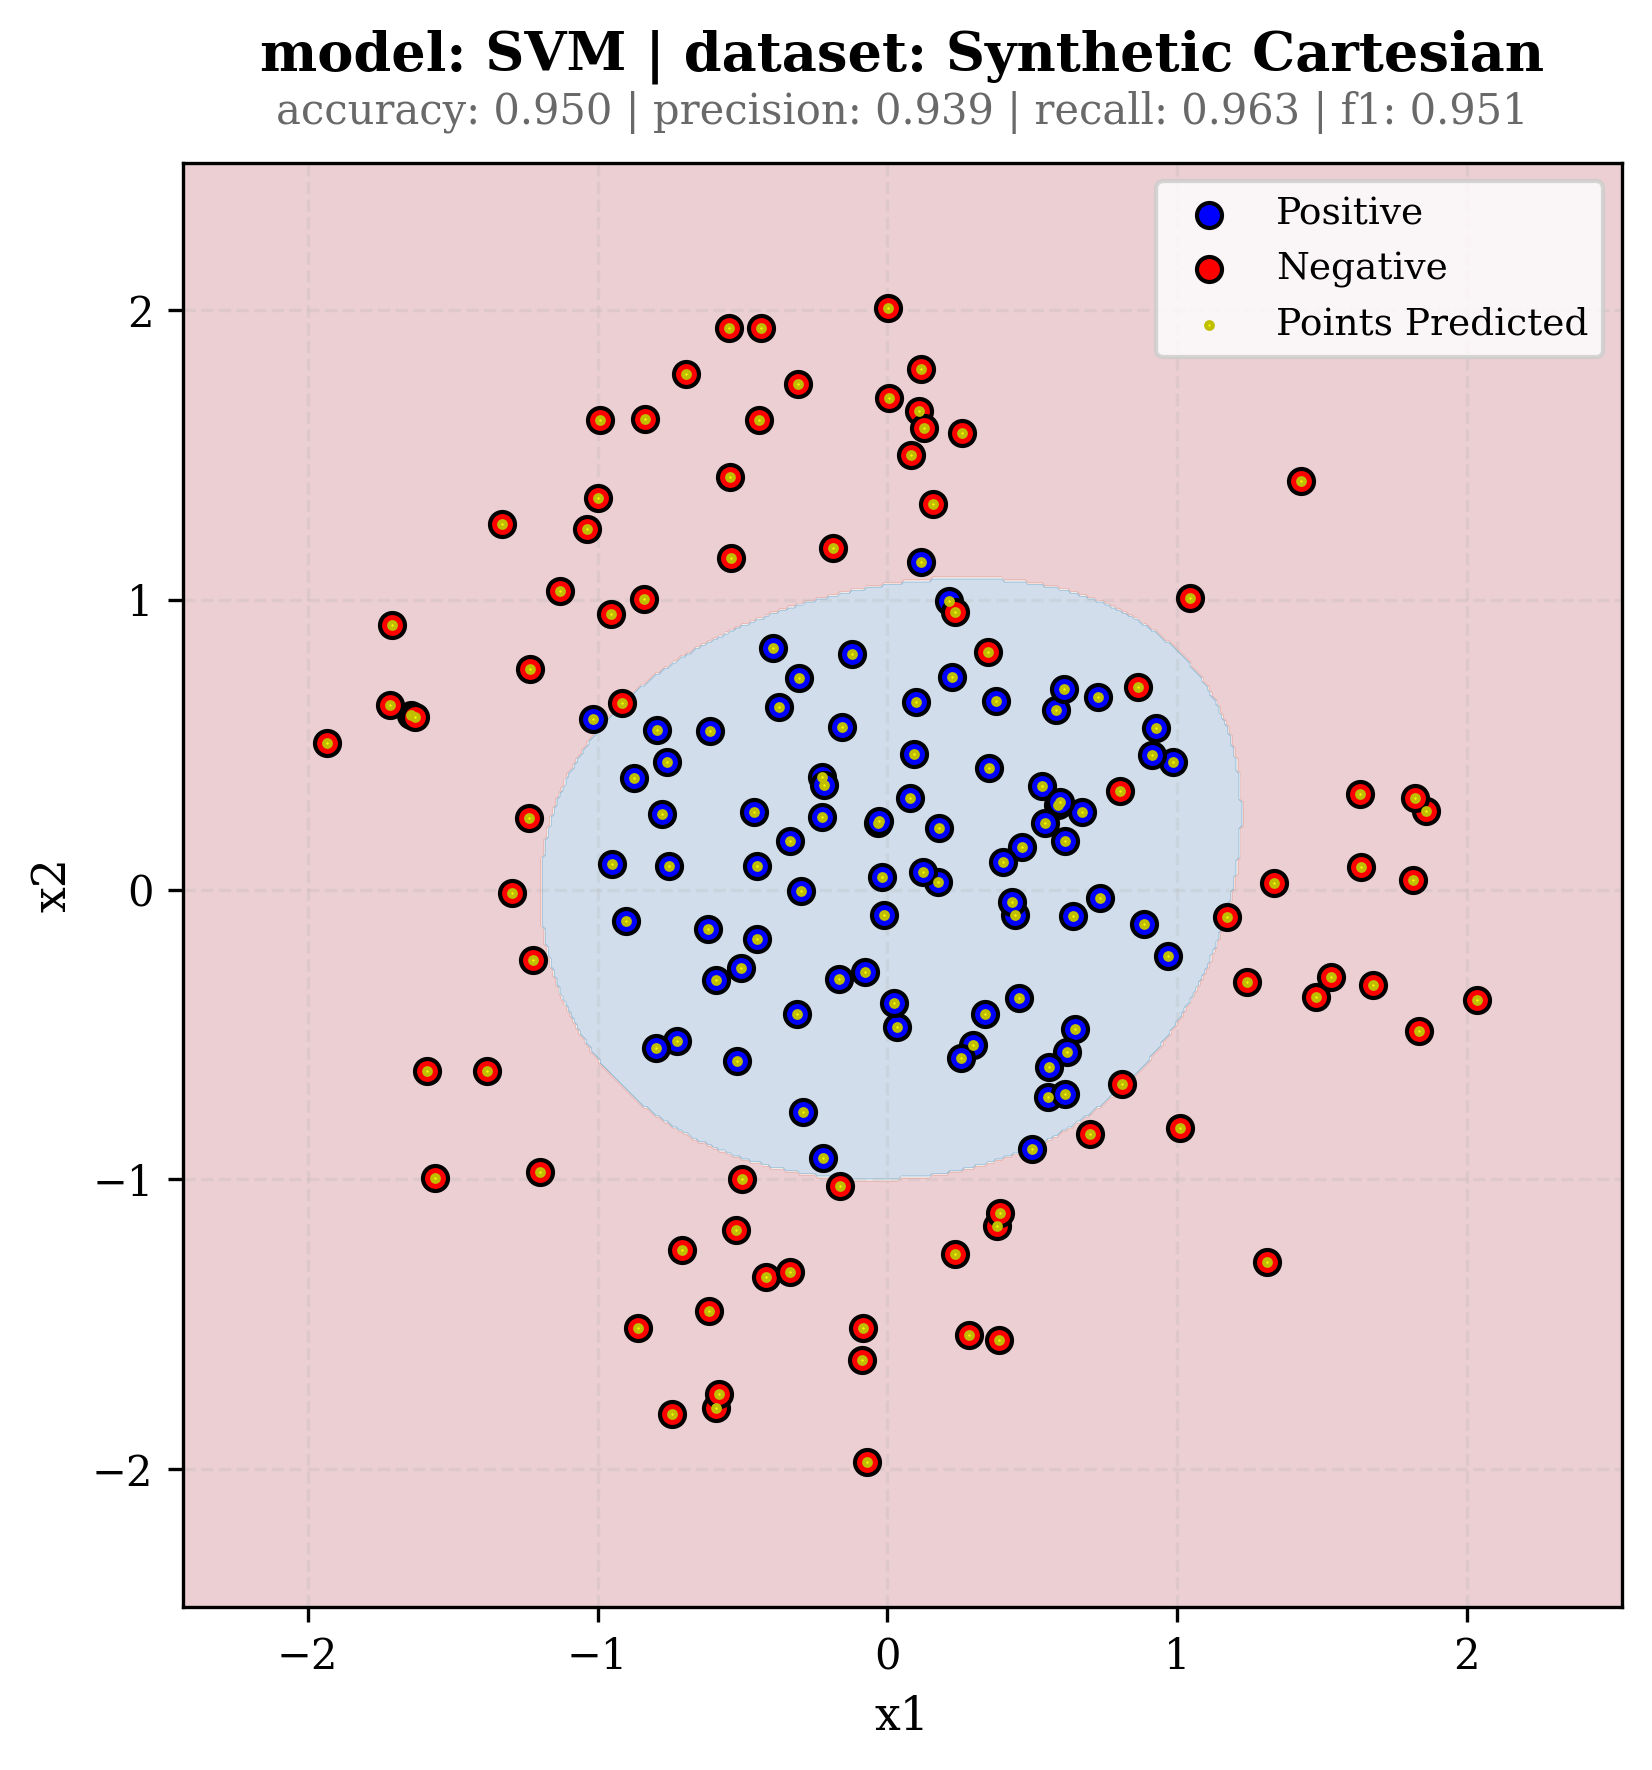

In [14]:
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(synth_cartesian_dataset.X, synth_cartesian_dataset.y)
svm_metrics = ModelMetrics('SVM', 'Cartesian', synth_cartesian_dataset.y, svm_model.predict(synth_cartesian_dataset.X))
svm_metrics.compute_metrics()
metrics_df = pd.concat([metrics_df, svm_metrics.to_pandas().rename(index={0:'SVM | Cartesian'})])

svm_fig, svm_ax = plot_decision_boundary(
    model=svm_model, dataset_X=synth_cartesian_dataset.X, dataset_y=synth_cartesian_dataset.y,
    prediction_domain=grid_cartesian, grid_x=grid_x, grid_y=grid_y,
    title=f'model: SVM | dataset: Synthetic Cartesian',
    metrics=svm_metrics.to_dict()
)
svm_ax.set_aspect('equal')
display(svm_fig)

### Sample Summary

In [15]:
metrics_df

,accuracy,precision,recall,f1
Generator decision boundary,0.93750,0.960526,0.9125,0.935897
Logistic Regression | Polar,0.95000,0.928571,0.9750,0.951220
Logistic Regression | R-only,0.95625,0.939759,0.9750,0.957055
Logistic Regression | Curvilinear,0.94375,0.917647,0.9750,0.945455
SVM | Cartesian,0.95000,0.939024,0.9625,0.950617


# Radially Symmetric Data with Noise

# Non-radially Symmetrical Data

In [17]:
synth_non_rad_polar_neg_dataset = generate_custom_polar_dataset(
    label=0,
    num_points=30,
    theta_lb=-np.pi/2,
    theta_ub=-np.pi/4,
    theta_pdf=lambda low, high, size: np.random.uniform(low, high, size)
)
synth_non_rad_polar_neg_dataset2 = generate_custom_polar_dataset(
    label=0,
    num_points=20,
    theta_lb=np.pi/2,
    theta_ub=3*np.pi/4,
    theta_pdf=lambda low, high, size: np.random.uniform(low, high, size)
    
)
synth_non_rad_polar_neg_dataset = PointsDataset.merge_dataset(synth_non_rad_polar_neg_dataset, synth_non_rad_polar_neg_dataset2)
synth_non_rad_polar_pos_dataset = generate_custom_polar_dataset(
    label=1,
    num_points=50,
    theta_lb=-np.pi,
    theta_ub=-np.pi/2,
    theta_pdf=lambda low, high, size: np.random.uniform(low, high, size),
    r_inner_bound_func=lambda theta: 0.2 * np.cos(theta)**2,
    r_outer_bound_func=lambda theta: 0.6 + 0.2 * np.cos(theta)**2,
    r_pdf=lambda low, high, size: np.random.uniform(low, high, size)
)

synth_non_rad_polar_dataset = PointsDataset.merge_dataset(synth_non_rad_polar_neg_dataset, synth_non_rad_polar_pos_dataset)


synth_cartesian_dataset = synth_non_rad_polar_dataset.transform(polar_to_cartesian)

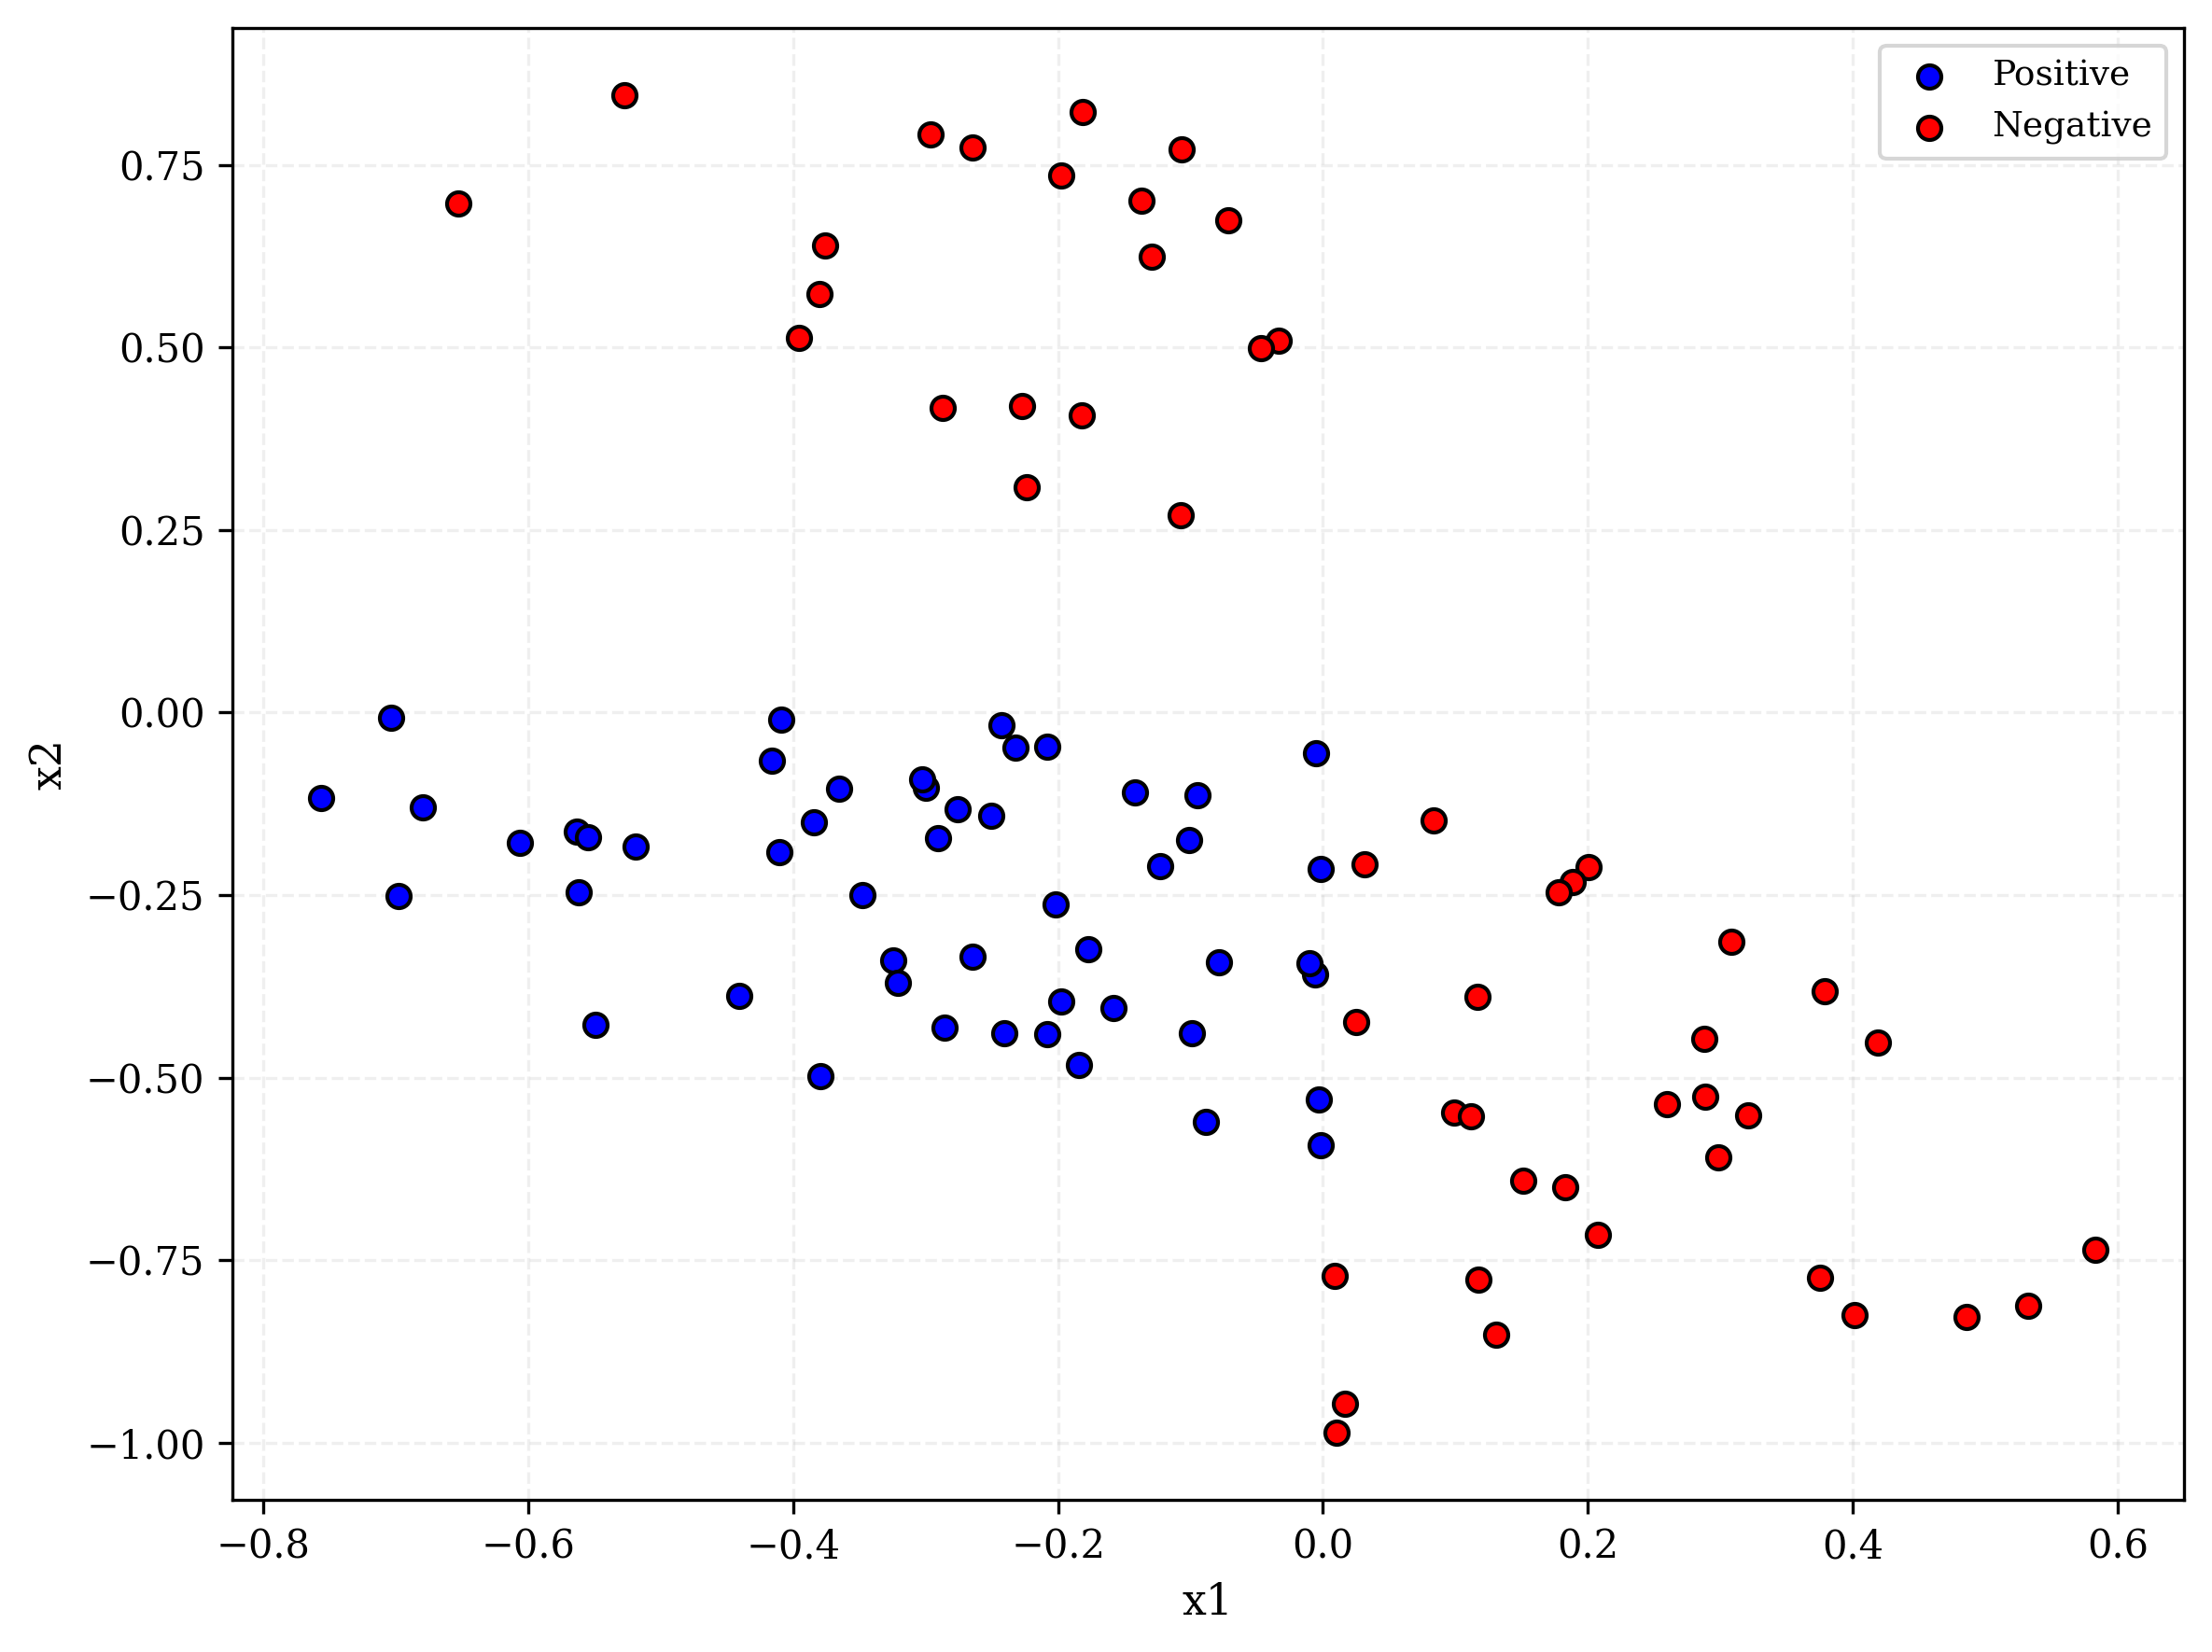

In [18]:
non_rad_fig, non_rad_ax = plot_in_rectangular_coordinates(
    synth_cartesian_dataset.X, 
    synth_cartesian_dataset.y,
    title=""
)
display(non_rad_fig)